In [ ]:
import numpy as np
import pandas as pd

----
### Import Menu Items file
----

In [ ]:
menu_items = pd.read_csv("menu_items.csv")
menu_items.head()

,menu_item_id,item_name,category,price
0,101,Hamburger,American,12.95
1,102,Cheeseburger,American,13.95
2,103,Hot Dog,American,9.00
3,104,Veggie Burger,American,10.50
4,105,Mac & Cheese,American,7.00


In [ ]:
menu_items.columns = ['item_id', 'item_name', 'category', 'price']

In [ ]:
menu_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   item_id    32 non-null     int64  
 1   item_name  32 non-null     object 
 2   category   32 non-null     object 
 3   price      32 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB


In [ ]:
menu_items.duplicated().sum()

0

----
### Import Order Details file
----

In [ ]:
order_details = pd.read_csv("order_details.csv")
order_details.head()

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,1/1/23,11:38:36 AM,109.0
1,2,2,1/1/23,11:57:40 AM,108.0
2,3,2,1/1/23,11:57:40 AM,124.0
3,4,2,1/1/23,11:57:40 AM,117.0
4,5,2,1/1/23,11:57:40 AM,129.0


In [ ]:
order_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  12234 non-null  int64  
 1   order_id          12234 non-null  int64  
 2   order_date        12234 non-null  object 
 3   order_time        12234 non-null  object 
 4   item_id           12097 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 478.0+ KB


#### Change type of column Item_id to Integer
----

In [ ]:
order_details['item_id'] = order_details['item_id'].astype('Int64')
order_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  12234 non-null  int64 
 1   order_id          12234 non-null  int64 
 2   order_date        12234 non-null  object
 3   order_time        12234 non-null  object
 4   item_id           12097 non-null  Int64 
dtypes: Int64(1), int64(2), object(2)
memory usage: 490.0+ KB


#### Concat Date & Time columns to make DateTime column and change its Type
----

In [ ]:
order_details['order_datetime'] = order_details['order_date'] + " " + order_details['order_time']
order_details['order_datetime'] = pd.to_datetime(order_details['order_datetime'])
order_details.info()

<ipython-input-49-231e8c311a96>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order_details['order_datetime'] = pd.to_datetime(order_details['order_datetime'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12234 non-null  int64         
 1   order_id          12234 non-null  int64         
 2   order_date        12234 non-null  object        
 3   order_time        12234 non-null  object        
 4   item_id           12097 non-null  Int64         
 5   order_datetime    12234 non-null  datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), int64(2), object(2)
memory usage: 585.5+ KB


In [ ]:
order_details.head()

,order_details_id,order_id,order_date,order_time,item_id,order_datetime
0,1,1,1/1/23,11:38:36 AM,109,2023-01-01 11:38:36
1,2,2,1/1/23,11:57:40 AM,108,2023-01-01 11:57:40
2,3,2,1/1/23,11:57:40 AM,124,2023-01-01 11:57:40
3,4,2,1/1/23,11:57:40 AM,117,2023-01-01 11:57:40
4,5,2,1/1/23,11:57:40 AM,129,2023-01-01 11:57:40


#### Drop order_date and order_time columns
----

In [ ]:
order_details.drop(['order_date', 'order_time'], axis= 1, inplace = True)
order_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12234 non-null  int64         
 1   order_id          12234 non-null  int64         
 2   item_id           12097 non-null  Int64         
 3   order_datetime    12234 non-null  datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), int64(2)
memory usage: 394.4 KB



#### Drop Null rows for item_id
----

In [ ]:
order_details.drop(order_details[order_details['item_id'].isna()].index, inplace = True)
order_details.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12097 entries, 0 to 12233
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12097 non-null  int64         
 1   order_id          12097 non-null  int64         
 2   item_id           12097 non-null  Int64         
 3   order_datetime    12097 non-null  datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), int64(2)
memory usage: 484.4 KB


In [ ]:
order_details.isna().sum()

,0
order_details_id,0
order_id,0
item_id,0
order_datetime,0


In [ ]:
order_details.duplicated().sum()

0

----
### Merging Tables
----

In [ ]:
df = pd.merge(order_details, menu_items, on='item_id', how='inner')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12097 entries, 0 to 12096
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12097 non-null  int64         
 1   order_id          12097 non-null  int64         
 2   item_id           12097 non-null  Int64         
 3   order_datetime    12097 non-null  datetime64[ns]
 4   item_name         12097 non-null  object        
 5   category          12097 non-null  object        
 6   price             12097 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 673.5+ KB


In [ ]:
df.columns

Index(['order_details_id', 'order_id', 'item_id', 'order_datetime',
       'item_name', 'category', 'price'],
      dtype='object')

### Setting Order_details_id as index
----

In [ ]:
df.set_index('order_details_id', inplace= True)
df.head(10)

,order_id,item_id,order_datetime,item_name,category,price
order_details_id,,,,,,
1,1,109,2023-01-01 11:38:36,Korean Beef Bowl,Asian,17.95
2,2,108,2023-01-01 11:57:40,Tofu Pad Thai,Asian,14.50
3,2,124,2023-01-01 11:57:40,Spaghetti,Italian,14.50
4,2,117,2023-01-01 11:57:40,Chicken Burrito,Mexican,12.95
5,2,129,2023-01-01 11:57:40,Mushroom Ravioli,Italian,15.50
6,2,106,2023-01-01 11:57:40,French Fries,American,7.00
7,3,117,2023-01-01 12:12:28,Chicken Burrito,Mexican,12.95
8,3,119,2023-01-01 12:12:28,Chicken Torta,Mexican,11.95
9,4,117,2023-01-01 12:16:31,Chicken Burrito,Mexican,12.95


----
### EDA
----

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_id,12097.0,2692.569149,1.0,1353.0,2711.0,4020.0,5370.0,1545.826452
item_id,12097.0,115.202282,101.0,107.0,114.0,123.0,132.0,9.38758
order_datetime,12097,2023-02-15 03:39:53.237000960,2023-01-01 11:38:36,2023-01-23 16:21:26,2023-02-14 20:00:33,2023-03-09 15:30:34,2023-03-31 22:15:48,NaN
price,12097.0,13.161767,5.0,10.5,13.95,16.5,19.95,3.986392


In [ ]:
df.describe(include='O')

,item_name,category
count,12097,12097
unique,32,4
top,Hamburger,Asian
freq,622,3470


## **Sales Performance Analysis**


1-What is the total revenue generated per category?



In [ ]:
df.groupby('category')['price'].sum().sort_values(ascending=False)

,price
category,
Italian,49462.70
Asian,46720.65
Mexican,34796.80
American,28237.75


2-
Which items contribute the most to revenue?


In [ ]:
df.groupby('item_name')['price'].sum().sort_values(ascending=False).head(10)

,price
item_name,
Korean Beef Bowl,10554.60
Spaghetti & Meatballs,8436.50
Tofu Pad Thai,8149.00
Cheeseburger,8132.85
Hamburger,8054.90
Orange Chicken,7524.00
Eggplant Parmesan,7119.00
Steak Torta,6821.55
Chicken Parmesan,6533.80


<Axes: xlabel='item_name'>

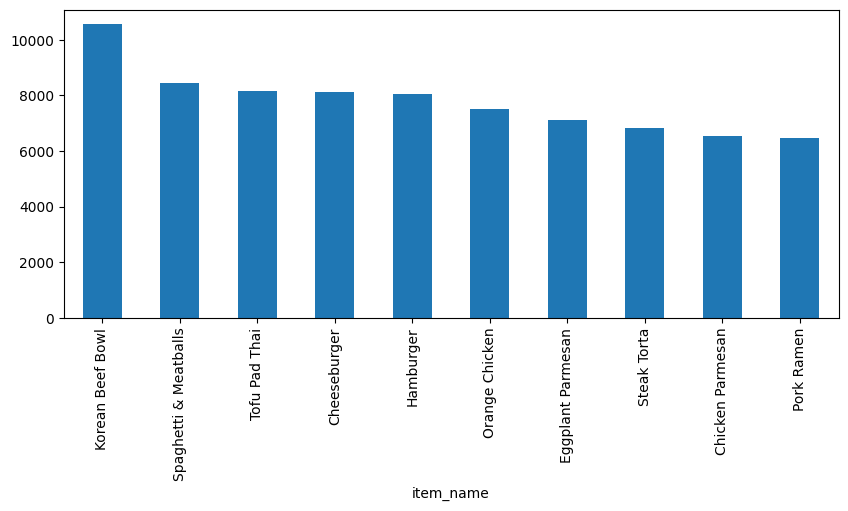

In [ ]:
df.groupby('item_name')['price'].sum().sort_values(ascending=False).head(10).plot.bar(figsize=(10,4))

3-What is the average order value (AOV) per category?
"AOV=Total Revenue/Total Number of Orders"


category
American    13.121631
Asian       17.730797
Italian     21.580585
Mexican     15.356046
dtype: float64


<Axes: xlabel='category'>

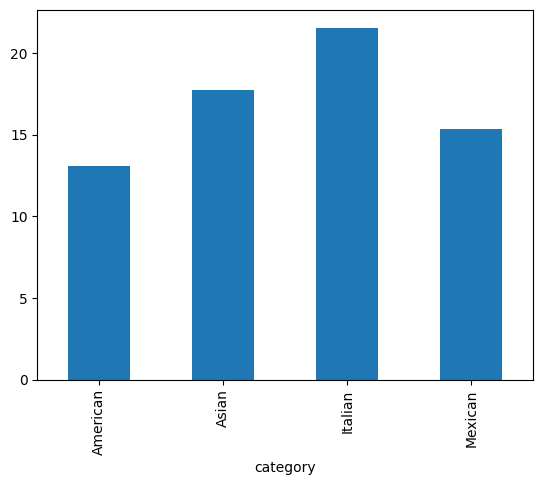

In [ ]:
category_revenue = df.groupby('category')['price'].sum()
category_orders = df.groupby('category')['order_id'].nunique()
aov_per_category = category_revenue / category_orders
print(aov_per_category)
aov_per_category.plot.bar()

4- How many unique items are sold in total, and what is the average price for items sold?

In [ ]:
print(f'There are {df["item_id"].nunique()} items, and the average price for items sold is {round(df["price"].unique().mean(), 2)}.')

There are 32 items, and the average price for items sold is 13.33.


## **Time-Based Analysis**


5- How does sales performance vary by time of day?



In [ ]:
df['order_hour'] = df['order_datetime'].dt.hour

In [ ]:
df_by_hour = df.groupby('order_hour')['price'].sum().reset_index()
df_by_hour.sort_values(by='order_hour')

,order_hour,price
0,10,63.35
1,11,8122.50
2,12,21718.40
3,13,20640.25
4,14,12615.70
5,15,9803.90
6,16,13711.65
7,17,17869.50
8,18,16861.50
9,19,14172.60


<Axes: xlabel='order_hour'>

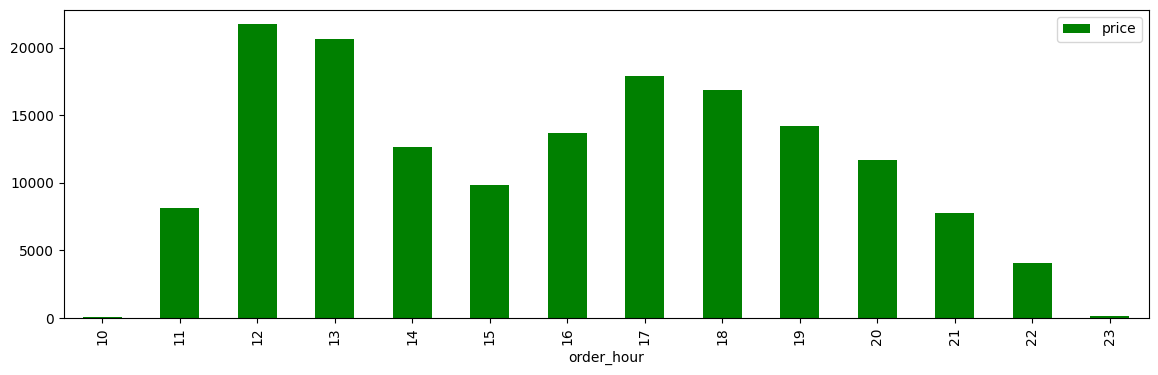

In [ ]:
df_by_hour.plot.bar(x='order_hour', figsize=(14, 4), color=['green'])

6- How does sales performance vary by day of week?

In [ ]:
df['order_day'] = df['order_datetime'].dt.day_name()
df_by_day = df.groupby('order_day')['price'].sum().reset_index()
df_by_day.sort_values(by='price', ascending=False)

,order_day,price
1,Monday,26007.45
0,Friday,23707.95
5,Tuesday,23356.00
3,Sunday,23226.45
4,Thursday,21846.85
2,Saturday,21170.90
6,Wednesday,19902.30


<Axes: xlabel='order_day'>

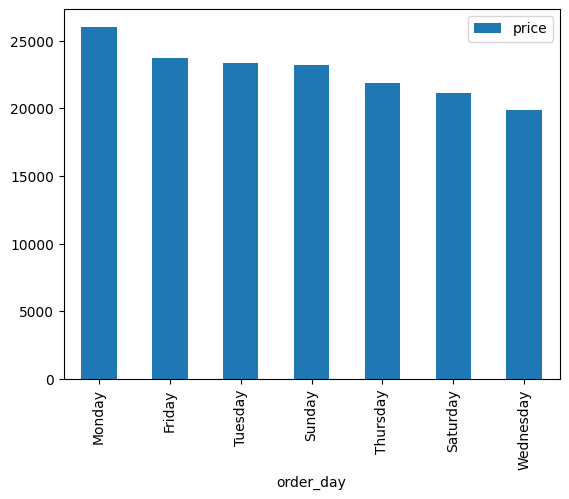

In [ ]:
df_by_day.sort_values(by='price', ascending=False).plot(kind='bar', x='order_day')

7- How does sales performance vary by Month?

In [ ]:
df['order_month'] = df['order_datetime'].dt.month
df.groupby('order_month')['price'].sum().sort_values(ascending=False)

,price
order_month,
3,54610.60
1,53816.95
2,50790.35


8- What is the average time gap between consecutive orders?

In [ ]:
df['order_day_number'] = df['order_datetime'].dt.day
time_diff = pd.DataFrame(columns = ['month', 'day', 'count_of_orders', 'diff'])

In [ ]:
month = 0
for j in range(3):
  month += 1
  if month ==21:
    days = 28
  else:
    days = 31
  for i in range(days):
    day = i+1
    count_of_orders = df[(df['order_month'] == month) & (df['order_day_number'] == day)]['order_id'].nunique()
    first_order_time = df[(df['order_month'] == month) & (df['order_day_number'] == day)]['order_datetime'].min()
    last_order_time = df[(df['order_month'] == month) & (df['order_day_number'] == day)]['order_datetime'].max()
    total_diff = last_order_time - first_order_time
    diff = total_diff / count_of_orders
    time_diff.loc[len(time_diff)] = [month, day, count_of_orders, diff]
time_diff['diff'] = time_diff['diff'].dt.total_seconds() / 60

<ipython-input-72-fd1f58ce5481>:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  time_diff.loc[len(time_diff)] = [month, day, count_of_orders, diff]
<ipython-input-72-fd1f58ce5481>:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  time_diff.loc[len(time_diff)] = [month, day, count_of_orders, diff]
<ipython-input-72-fd1f58ce5481>:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA 

In [ ]:
time_diff.groupby('month')['diff'].mean()

,diff
month,
1,10.936209
2,11.107292
3,11.010748


9- Are there specific times when certain categories sell more?

In [ ]:
df.groupby(['order_month', 'item_name'])['price'].sum().sort_values(ascending=False)
df.groupby(['order_month', 'category'])['price'].sum().sort_values()

order_month  category
2            American     8947.15
1            American     9284.85
3            American    10005.75
2            Mexican     11222.45
3            Mexican     11358.50
1            Mexican     12215.85
2            Asian       15075.70
             Italian     15545.05
1            Asian       15588.50
3            Asian       16056.45
1            Italian     16727.75
3            Italian     17189.90
Name: price, dtype: float64

10-What is the growth rate of orders over time?

In [ ]:
df.resample('M', on='order_datetime')['order_id'].nunique()


<ipython-input-75-7e79cd6e7f63>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='order_datetime')['order_id'].nunique()


,order_id
order_datetime,
2023-01-31,1835
2023-02-28,1675
2023-03-31,1833


## **Customer Bahavior Analysis**


11-What is the average number of items per order?

In [ ]:
number_of_items = df['item_name'].count()
number_of_orders = df['order_id'].max()
print(f"Number of Items : {number_of_items}")
print(f"Number of Orders : {number_of_orders}")
print(f"Average number of items / order : {round(number_of_items/number_of_orders, 2)}")

Number of Items : 12097
Number of Orders : 5370
Average number of items / order : 2.25


12-Which items are frequently bought together?

In [ ]:
items = df['item_name'].unique()
items_2 = []
for item in items:
  items_2.append(item)
print(len(items))
print(len(items_2))

32
32


In [ ]:
bought_together = pd.DataFrame(columns = ['item_1', 'item_2', 'times'])
bought_together

,item_1,item_2,times


In [ ]:
for a in items:
    for b in items_2:
        if a != b:
            df1 = df[df['item_name'] == a][['item_name', 'order_id']]
            df2 = df[df['item_name'] == b][['item_name', 'order_id']]
            df3 = pd.merge(df1, df2, how='inner', on='order_id')
            c = df3['order_id'].nunique()
            bought_together.loc[len(bought_together)] = [a, b, c]
    items_2.remove(a)

<Axes: xlabel='item_1'>

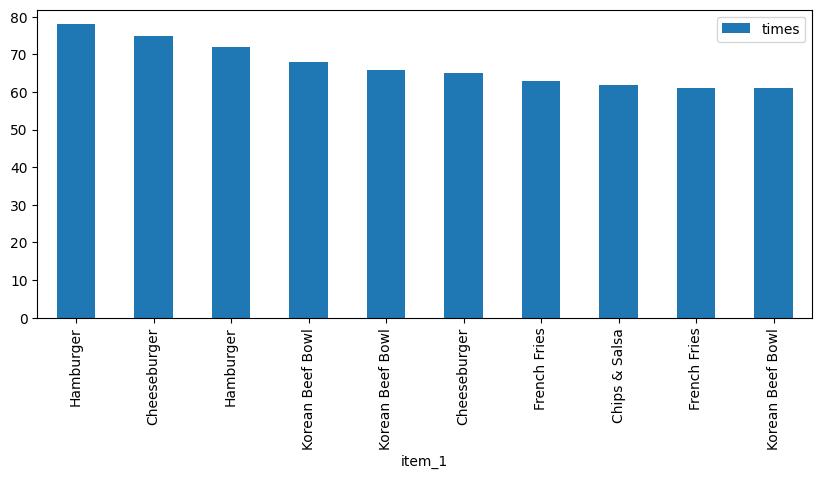

In [ ]:
bought_together_sorted = bought_together.sort_values('times', ascending=False, ignore_index=True)
bought_together_sorted.index = range(1, len(bought_together_sorted) + 1)
bought_together_sorted.head(10).plot.bar(x='item_1',y='times', figsize=(10,4))

In [ ]:
repeat_purchases = df.groupby(['order_id', 'item_name']).size().reset_index(name='count')
repeat_purchases[repeat_purchases['count'] > 1].sort_values(by='count', ascending=False).head(10)

,order_id,item_name,count
8659,3940,Eggplant Parmesan,3
6048,2781,French Fries,3
5141,2364,Meat Lasagna,3
9495,4314,Eggplant Parmesan,3
3553,1639,Korean Beef Bowl,3
4663,2143,Tofu Pad Thai,3
7970,3635,Mac & Cheese,3
1602,740,Chicken Parmesan,3
7354,3364,Veggie Burger,2
7442,3403,Steak Burrito,2


<Axes: xlabel='item_name'>

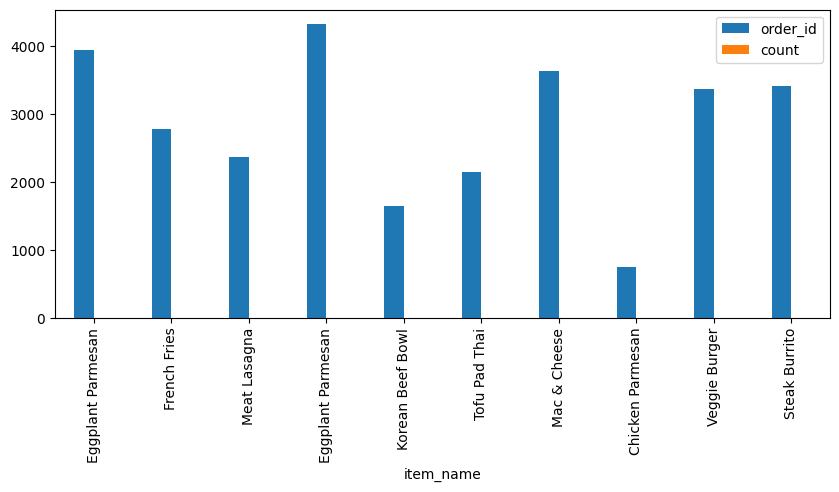

In [ ]:
repeat_purchases[repeat_purchases['count'] > 1].sort_values(by='count', ascending=False).head(10).plot.bar(x='item_name', figsize=(10,4))

## **Pricing and Profitability Analysis**

14-How does pricing affect sales volume for specific items?

In [ ]:
df.groupby('item_id')['price'].mean().corr(df.groupby('item_id')['order_id'].count())

-0.09010595054636056


 15-Are there any pricing trends or discounts that impact sales?


<Axes: xlabel='order_month'>

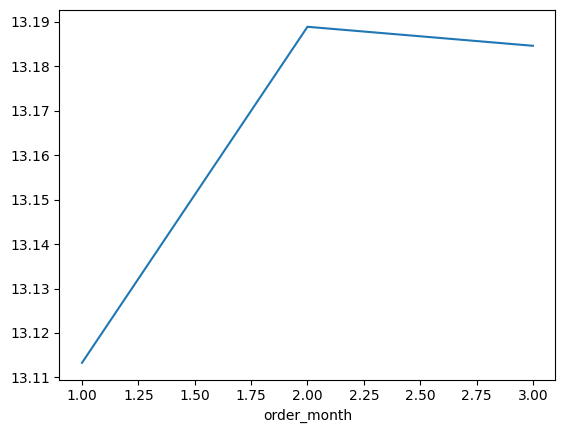

In [ ]:
df.groupby('order_month')['price'].mean().plot()

16-What is the distribution of sales across price ranges?

<ipython-input-85-2dd6b599b78f>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_range')['order_id'].count().plot(kind='bar')


<Axes: xlabel='price_range'>

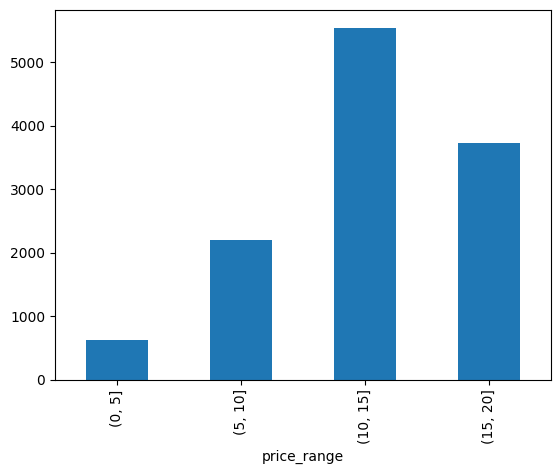

In [ ]:
df['price_range'] = pd.cut(df['price'], bins=[0,5,10,15,20])
df.groupby('price_range')['order_id'].count().plot(kind='bar')